# Day 2 — Feature Engineering

We are working with the merged dataset from Day 1. The goal today is to turn raw transaction data into features that actually mean something to a fraud detection model. Every feature we build comes from a pattern we spotted in the EDA — high fraud hours, card probe amounts, mobile devices, email mismatches and more.

By the end we have 19 new features saved to a pickle file so we never have to rebuild from scratch again.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading both files and merging them straight away
# left join so we keep all 590k transactions, identity data fills in where available
trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

df = trans.merge(identity, on='TransactionID', how='left')

print("Transaction shape:", trans.shape)
print("Identity shape:", identity.shape)
print("Merged shape:", df.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)
Merged shape: (590540, 434)


In [2]:
# checking how much data is missing before we do anything
# some columns are 90%+ empty which makes them useless
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

high_missing = missing[missing > 70]
medium_missing = missing[(missing > 30) & (missing <= 70)]
low_missing = missing[(missing > 0) & (missing <= 30)]
no_missing = missing[missing == 0]

print(f"Columns with >70% missing: {len(high_missing)}")
print(f"Columns with 30-70% missing: {len(medium_missing)}")
print(f"Columns with 0-30% missing: {len(low_missing)}")
print(f"Columns with no missing: {len(no_missing)}")

Columns with >70% missing: 208
Columns with 30-70% missing: 24
Columns with 0-30% missing: 182
Columns with no missing: 20


In [3]:
# three strategies for missing data:
# drop anything over 90% missing - too sparse to be useful
# fill numerical with median - more robust than mean because of extreme outliers like $31k transactions
# fill categorical with 'Unknown' - honest, and absence of info can itself be a signal

threshold = 90
cols_to_drop = missing[missing > threshold].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >90% missing")
df = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {df.shape[1]}")

numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

df = df.copy()

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Dropping 12 columns with >90% missing
Remaining columns: 422

Missing values remaining: 0
Final shape: (590540, 422)


In [4]:
# TransactionDT is seconds since a reference point, not a real timestamp
# but we can still pull out hour and day patterns
# from EDA we know fraud spikes at hours 1-9 when volume is low and people are asleep

df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['is_late_night'] = df['hour'].apply(lambda x: 1 if 1 <= x <= 9 else 0)

print("Time features created:")
print(df[['hour', 'day', 'is_late_night']].head(10))
print(f"\nLate night transactions: {df['is_late_night'].sum():,}")
print(f"Late night fraud rate: {df[df['is_late_night']==1]['isFraud'].mean()*100:.2f}%")
print(f"Normal hours fraud rate: {df[df['is_late_night']==0]['isFraud'].mean()*100:.2f}%")

Time features created:
   hour  day  is_late_night
0     0    1              0
1     0    1              0
2     0    1              0
3     0    1              0
4     0    1              0
5     0    1              0
6     0    1              0
7     0    1              0
8     0    1              0
9     0    1              0

Late night transactions: 119,652
Late night fraud rate: 4.68%
Normal hours fraud rate: 3.20%


In [5]:
# three amount features based on patterns from EDA
# log_amount compresses the huge range ($0.25 to $32k) so the model can learn from it
# is_card_probe catches tiny transactions under $1 - fraudsters test stolen cards this way
# is_threshold_avoid catches $500-$1000 range - deliberate avoidance of $1k review triggers

df['log_amount'] = np.log1p(df['TransactionAmt'])
df['is_card_probe'] = (df['TransactionAmt'] < 1).astype(int)
df['is_threshold_avoid'] = ((df['TransactionAmt'] >= 500) & 
                             (df['TransactionAmt'] < 1000)).astype(int)

print("Amount features created:")
print(f"Card probe transactions: {df['is_card_probe'].sum():,}")
print(f"Card probe fraud rate: {df[df['is_card_probe']==1]['isFraud'].mean()*100:.2f}%")
print(f"\nThreshold avoidance transactions: {df['is_threshold_avoid'].sum():,}")
print(f"Threshold avoidance fraud rate: {df[df['is_threshold_avoid']==1]['isFraud'].mean()*100:.2f}%")

Amount features created:
Card probe transactions: 152
Card probe fraud rate: 14.47%

Threshold avoidance transactions: 16,744
Threshold avoidance fraud rate: 5.75%


In [6]:
# transactions with identity data have much higher fraud rate than those without
# because identity data comes from online purchases and that's where card-not-present fraud lives
# mobile also has higher fraud rate than desktop

df['has_identity'] = df['DeviceType'].apply(
    lambda x: 0 if x == 'Unknown' else 1)

df['is_mobile'] = df['DeviceType'].apply(
    lambda x: 1 if x == 'mobile' else 0)

print("Identity features created:")
print(f"Transactions with identity: {df['has_identity'].sum():,}")
print(f"Fraud rate with identity: {df[df['has_identity']==1]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate without identity: {df[df['has_identity']==0]['isFraud'].mean()*100:.2f}%")
print(f"\nMobile transactions: {df['is_mobile'].sum():,}")
print(f"Mobile fraud rate: {df[df['is_mobile']==1]['isFraud'].mean()*100:.2f}%")
print(f"Desktop fraud rate: {df[df['is_mobile']==0]['isFraud'].mean()*100:.2f}%")

Identity features created:
Transactions with identity: 140,810
Fraud rate with identity: 7.96%
Fraud rate without identity: 2.10%

Mobile transactions: 55,645
Mobile fraud rate: 10.17%
Desktop fraud rate: 2.81%


In [7]:
# a single transaction tells us little, but compared to that card's history it tells us a lot
# card1_count - how many transactions this card has made total
# card1_mean_amt - what this card normally spends
# amt_deviation_ratio - how far THIS transaction is from that card's normal behaviour

card_counts = df.groupby('card1')['TransactionAmt'].count().reset_index()
card_counts.columns = ['card1', 'card1_count']
df = df.merge(card_counts, on='card1', how='left')

card_mean = df.groupby('card1')['TransactionAmt'].mean().reset_index()
card_mean.columns = ['card1', 'card1_mean_amt']
df = df.merge(card_mean, on='card1', how='left')

df['amt_deviation'] = abs(df['TransactionAmt'] - df['card1_mean_amt'])
df['amt_deviation_ratio'] = df['amt_deviation'] / (df['card1_mean_amt'] + 1)

print("Card aggregation features created:")
print(df[['card1', 'card1_count', 'card1_mean_amt', 
          'TransactionAmt', 'amt_deviation_ratio']].head(10))

high_dev = df[df['amt_deviation_ratio'] > 2]
print(f"\nHigh deviation transactions: {len(high_dev):,}")
print(f"High deviation fraud rate: {high_dev['isFraud'].mean()*100:.2f}%")
print(f"Normal deviation fraud rate: {df[df['amt_deviation_ratio']<=2]['isFraud'].mean()*100:.2f}%")

Card aggregation features created:
   card1  card1_count  card1_mean_amt  TransactionAmt  amt_deviation_ratio
0  13926           43      351.931163            68.5             0.803078
1   2755          683      234.292753            29.0             0.872499
2   4663         1108       97.015542            59.0             0.387852
3  18132         4209      123.416340            50.0             0.590086
4   4497           18       96.972222            50.0             0.479444
5   5937            7      134.071429            49.0             0.629825
6  12308          207      101.880097           159.0             0.555208
7  12695         7091      141.144645           422.5             1.979360
8   2803         6141      142.683409            15.0             0.888644
9  17399         1916      122.020491           117.0             0.040810

High deviation transactions: 26,817
High deviation fraud rate: 5.03%
Normal deviation fraud rate: 3.43%


In [8]:
# free email providers are slightly riskier - easy to create anonymously
# email_match is counterintuitive - when purchaser and recipient email match it's actually higher fraud
# that's an account takeover signal, the attacker is shipping goods to themselves

free_emails = ['gmail.com', 'yahoo.com', 'hotmail.com', 
               'outlook.com', 'aol.com', 'mail.com']

df['is_free_email'] = df['P_emaildomain'].apply(
    lambda x: 1 if x in free_emails else 0)

df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

print("Email features created:")
print(f"\nFree email fraud rate: {df[df['is_free_email']==1]['isFraud'].mean()*100:.2f}%")
print(f"Non-free email fraud rate: {df[df['is_free_email']==0]['isFraud'].mean()*100:.2f}%")
print(f"\nEmail match fraud rate: {df[df['email_match']==1]['isFraud'].mean()*100:.2f}%")
print(f"Email mismatch fraud rate: {df[df['email_match']==0]['isFraud'].mean()*100:.2f}%")

Email features created:

Free email fraud rate: 3.88%
Non-free email fraud rate: 2.65%

Email match fraud rate: 6.47%
Email mismatch fraud rate: 2.13%


In [9]:
# instead of label encoding (visa=1, mastercard=2 which means nothing)
# we replace each category with its actual fraud rate
# so the model gets the real risk signal directly

def fraud_rate_encode(df, col):
    fraud_rates = df.groupby(col)['isFraud'].mean()
    return df[col].map(fraud_rates)

df['product_fraud_rate'] = fraud_rate_encode(df, 'ProductCD')
df['card4_fraud_rate'] = fraud_rate_encode(df, 'card4')
df['card6_fraud_rate'] = fraud_rate_encode(df, 'card6')

print("Fraud rate encoding done:")
print(df[['ProductCD', 'product_fraud_rate', 
          'card4', 'card4_fraud_rate']].drop_duplicates('ProductCD'))

Fraud rate encoding done:
   ProductCD  product_fraud_rate             card4  card4_fraud_rate
0          W            0.020399          discover          0.077282
4          H            0.047662        mastercard          0.034331
10         C            0.116873        mastercard          0.034331
38         S            0.058996  american express          0.028698
99         R            0.037826              visa          0.034756


In [10]:
# velocity = how rapidly a card is being used
# amount_diversity = does this card use many different amounts or the same ones repeatedly
# low diversity can mean automated fraud scripting
# note: raw velocity alone wasn't a strong signal - high use cards are often just frequent legit users

df_model = df.copy()
df_model = df_model.sort_values('TransactionDT' if 'TransactionDT' in df_model.columns else 'TransactionID').reset_index(drop=True)

velocity = df_model.groupby('card1')['TransactionID'].count().reset_index()
velocity.columns = ['card1', 'card1_velocity']
df_model = df_model.merge(velocity, on='card1', how='left')

unique_amounts = df_model.groupby('card1')['TransactionAmt'].nunique().reset_index()
unique_amounts.columns = ['card1', 'card1_unique_amounts']
df_model = df_model.merge(unique_amounts, on='card1', how='left')

df_model['amount_diversity'] = df_model['card1_unique_amounts'] / df_model['card1_velocity']

high_vel = df_model[df_model['card1_velocity'] > df_model['card1_velocity'].quantile(0.75)]
low_vel = df_model[df_model['card1_velocity'] <= df_model['card1_velocity'].quantile(0.75)]

print(f"High velocity card fraud rate: {high_vel['isFraud'].mean()*100:.2f}%")
print(f"Low velocity card fraud rate: {low_vel['isFraud'].mean()*100:.2f}%")
print(f"\nAmount diversity sample:")
print(df_model[['card1', 'card1_velocity', 'card1_unique_amounts', 'amount_diversity']].head(5))

High velocity card fraud rate: 3.38%
Low velocity card fraud rate: 3.54%

Amount diversity sample:
   card1  card1_velocity  card1_unique_amounts  amount_diversity
0  13926              43                    28          0.651163
1   2755             683                   233          0.341142
2   4663            1108                   228          0.205776
3  18132            4209                   462          0.109765
4   4497              18                    10          0.555556


/tmp/ipykernel_17/2107114813.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_bin = df_model.groupby(bins)['isFraud'].mean() * 100
/tmp/ipykernel_17/2107114813.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_bin = df_model.groupby(bins)['isFraud'].mean() * 100


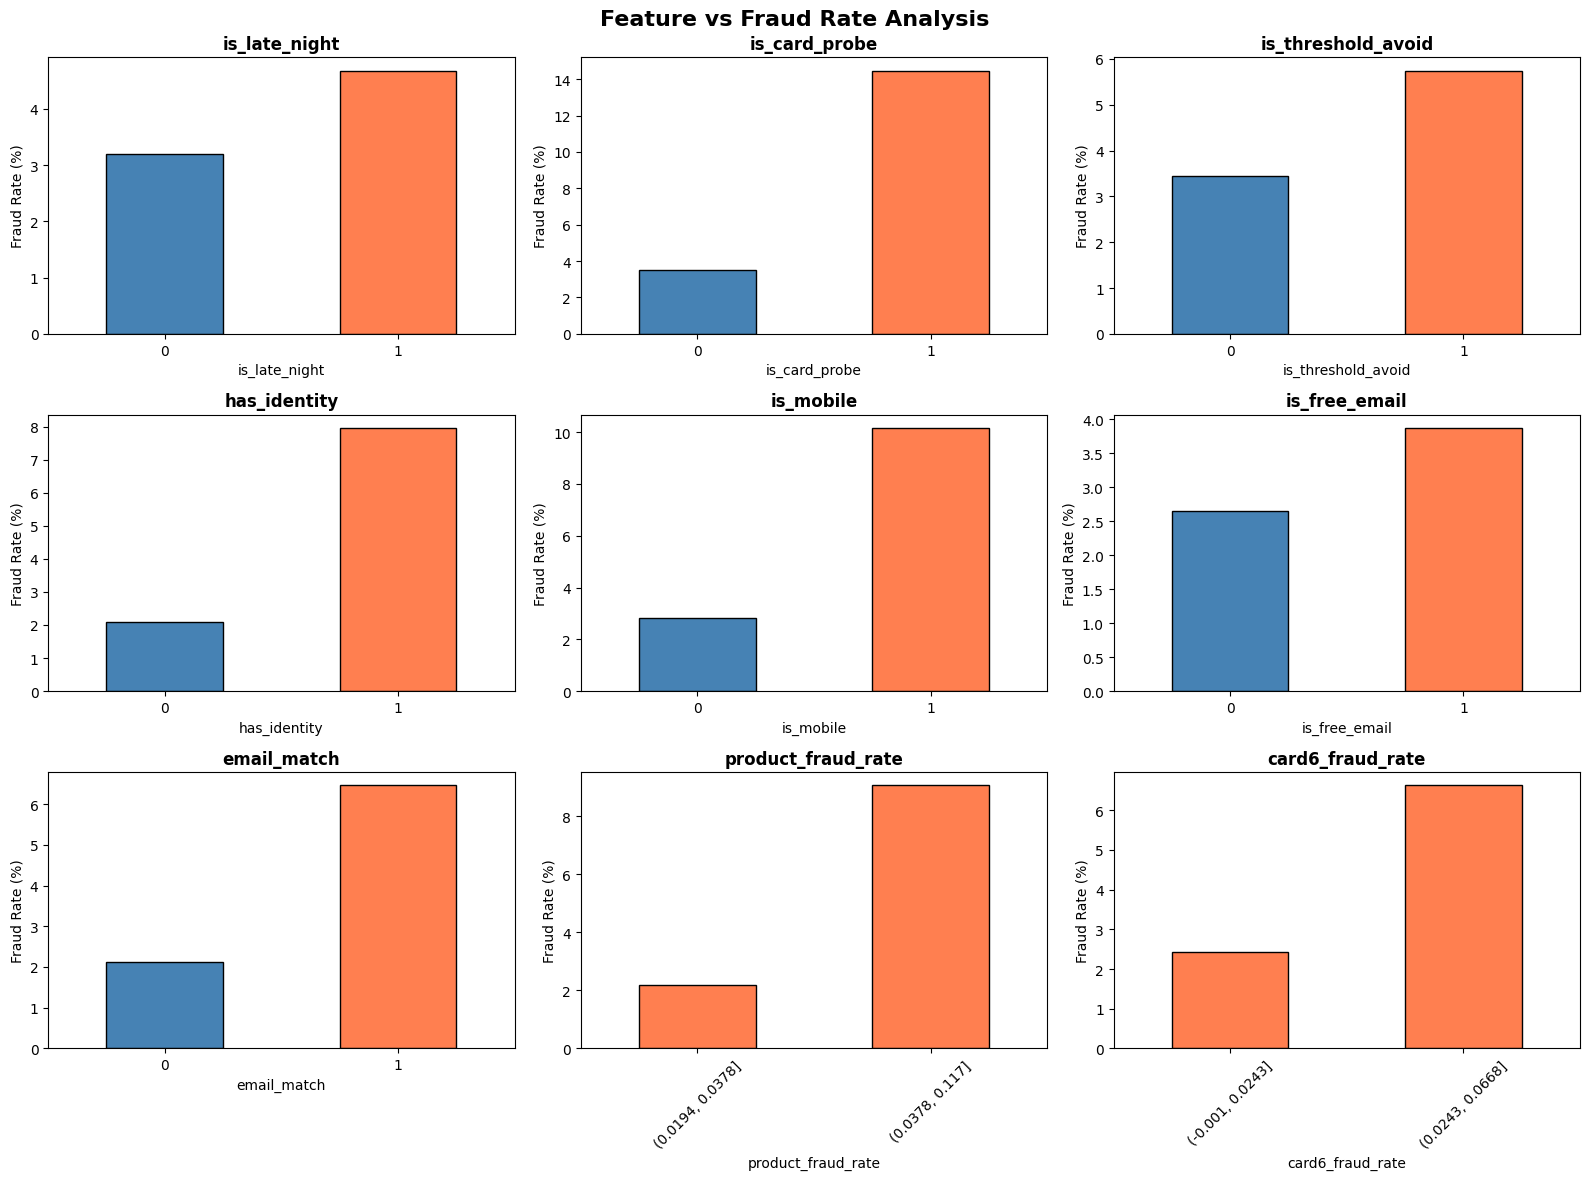

Visualization saved!


In [11]:
# every feature we built should show a clear difference in fraud rate between its values
# if it doesn't, the model won't learn anything from it
# this chart validates all 9 key features at once

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Feature vs Fraud Rate Analysis', fontsize=16, fontweight='bold')

features = ['is_late_night', 'is_card_probe', 'is_threshold_avoid',
            'has_identity', 'is_mobile', 'is_free_email', 
            'email_match', 'product_fraud_rate', 'card6_fraud_rate']

for idx, feature in enumerate(features):
    ax = axes[idx//3][idx%3]
    
    if df_model[feature].nunique() <= 2:
        fraud_rates = df_model.groupby(feature)['isFraud'].mean() * 100
        fraud_rates.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], 
                        edgecolor='black')
        ax.set_title(f'{feature}', fontweight='bold')
        ax.set_ylabel('Fraud Rate (%)')
        ax.tick_params(axis='x', rotation=0)
    else:
        bins = pd.qcut(df_model[feature], q=10, duplicates='drop')
        fraud_by_bin = df_model.groupby(bins)['isFraud'].mean() * 100
        fraud_by_bin.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
        ax.set_title(f'{feature}', fontweight='bold')
        ax.set_ylabel('Fraud Rate (%)')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/kaggle/working/feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

In [12]:
# saving as pickle not csv because it's much faster to load for large dataframes
# this file survives session resets so we never have to rebuild features again

df_model.to_pickle('/kaggle/working/model_data.pkl')
print("Data updated and saved!")
print("Final shape:", df_model.shape)
print("Total features ready for modeling:", df_model.shape[1] - 3,
      "(minus TransactionID, isFraud, card columns)")

new_features = ['hour', 'day', 'is_late_night', 'log_amount', 
                'is_card_probe', 'is_threshold_avoid', 'has_identity',
                'is_mobile', 'card1_count', 'card1_mean_amt', 
                'amt_deviation_ratio', 'is_free_email', 'email_match',
                'product_fraud_rate', 'card4_fraud_rate', 'card6_fraud_rate',
                'card1_velocity', 'card1_unique_amounts', 'amount_diversity']

print("\nFeatures created today:")
for f in new_features:
    print(f"  {f}")

Data updated and saved!
Final shape: (590540, 442)
Total features ready for modeling: 439 (minus TransactionID, isFraud, card columns)

Features created today:
  hour
  day
  is_late_night
  log_amount
  is_card_probe
  is_threshold_avoid
  has_identity
  is_mobile
  card1_count
  card1_mean_amt
  amt_deviation_ratio
  is_free_email
  email_match
  product_fraud_rate
  card4_fraud_rate
  card6_fraud_rate
  card1_velocity
  card1_unique_amounts
  amount_diversity


---
## Quick Session Restore

If the Kaggle session resets, just run this one cell and everything is back:

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_model = pd.read_pickle('/kaggle/working/model_data.pkl')
print("Ready! Shape:", df_model.shape)

Ready! Shape: (590540, 442)
